# CH 6 : RULE DATA MINING AS A SPECIFICATION SEARCH - RULE SEARCHING

> **Eurêka final :** la **recherche de règles** ne cherche pas seulement le meilleur réglage d’une stratégie déjà choisie. Elle met en compétition plusieurs **formes logiques** de stratégies, puis sélectionne celle qui obtient le meilleur score historique.

Dans ce notebook, on va transformer l’idée de David Aronson en intuition concrète, puis en exemple Python orienté **trading** et **backtest**.

L’objectif est de comprendre pourquoi la **rule searching** est plus puissante que la simple optimisation de paramètres, mais aussi pourquoi elle augmente fortement le **biais de minage de données**.


## 1. L’idée en une phrase

La **recherche de règles** consiste à tester plusieurs familles de stratégies différentes.

Par exemple :

| Type de recherche | Ce que l’on change | Exemple |
|---|---:|---|
| **Optimisation des paramètres** | Seulement les valeurs numériques | Moyenne mobile 10, 20, 50, 100 jours |
| **Recherche de règles** | La logique de la règle + ses paramètres | Moyennes mobiles, RSI, breakout, mean reversion |

> La différence essentielle : dans l’optimisation, tu supposes déjà connaître la bonne logique. Dans la **rule searching**, tu laisses plusieurs logiques se battre entre elles.


## 2. L’analogie simple

Imagine que tu veux trouver la meilleure recette.

L’**optimisation des paramètres**, c’est comme tester plusieurs dosages de sucre pour une seule recette de gâteau.

La **recherche de règles**, c’est tester :

- des recettes de gâteaux ;
- des recettes de tartes ;
- des recettes de biscuits ;
- puis plusieurs dosages pour chaque recette.

C’est plus large, donc potentiellement plus puissant.

Mais c’est aussi plus dangereux statistiquement.

Pourquoi ?

Parce que plus tu testes de recettes, plus tu augmentes la probabilité d’en trouver une qui a eu l’air excellente **par hasard**.


## 3. Traduction EBTA

En trading algorithmique, une **règle** est une transformation logique des données de marché en positions.

Par exemple :

| Famille de règle | Intuition de marché | Signal possible |
|---|---|---|
| **Trend following** | Le marché continue dans sa direction | Acheter si le prix casse un plus haut |
| **Mean reversion** | Le marché revient vers sa moyenne | Acheter après une baisse extrême |
| **Momentum** | La force récente continue | Acheter si le rendement récent est positif |
| **Divergence** | Le prix et un indicateur se désalignent | Acheter si l’indicateur monte mais pas le prix |

Dans la **rule searching**, on ne teste pas seulement un indicateur.

On teste plusieurs visions du marché.

> La question devient : quelle philosophie de marché semble la mieux fonctionner sur cet historique ?


## 4. La structure mathématique du problème

On peut représenter un univers de règles comme un ensemble de candidats :

$$
\mathcal{R} = \{R_1, R_2, R_3, ..., R_N\}
$$

Chaque règle $R_i$ produit une série de rendements de stratégie :

$$
r_{i,t} = \text{position}_{i,t-1} \times \text{return}_{t}
$$

Puis on donne un score à chaque règle, par exemple la moyenne annualisée :

$$
\text{Score}(R_i) = 252 \times \bar{r}_i
$$

La recherche sélectionne la meilleure règle :

$$
R^* = \arg\max_{R_i \in \mathcal{R}} \text{Score}(R_i)
$$

Le piège est ici :

> Même si toutes les règles sont nulles en réalité, la meilleure règle historique peut sembler excellente simplement parce qu’on a testé beaucoup de candidates.


## 5. Exemple Python : créer un mini-marché artificiel

On va générer une série de prix synthétique.

Important : ce marché n’a volontairement **aucun edge évident**. Il est proche d’une marche aléatoire.

Cela permet de voir comment une recherche de règles peut malgré tout trouver une stratégie apparemment intéressante.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_days = 1500

# Rendements quotidiens simulés : bruit autour de 0
returns = np.random.normal(loc=0.0001, scale=0.01, size=n_days)

prices = 100 * np.exp(np.cumsum(returns))

data = pd.DataFrame({
    "price": prices,
    "return": returns
})

data.head()


,price,return
0,100.508000,0.005067
1,100.379167,-0.001283
2,101.041525,0.006577
3,102.602456,0.015330
4,102.372727,-0.002242


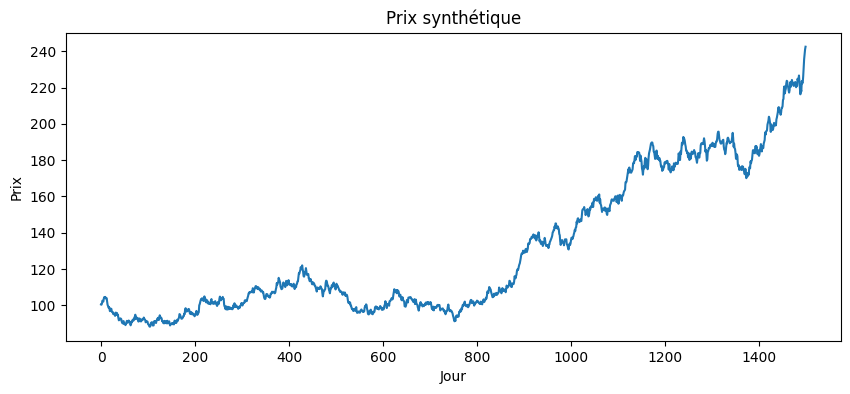

In [2]:
plt.figure(figsize=(10, 4))
plt.plot(data["price"])
plt.title("Prix synthétique")
plt.xlabel("Jour")
plt.ylabel("Prix")
plt.show()


## 6. Définir plusieurs familles de règles

On va créer trois familles très simples :

1. **Trend breakout** : acheter si le prix dépasse son plus haut récent.
2. **Mean reversion** : acheter si le prix est très bas par rapport à sa moyenne.
3. **Momentum** : acheter si le rendement récent est positif.

Chaque famille aura plusieurs paramètres.

C’est exactement l’esprit de la **rule searching** :

$$
\text{plusieurs formes logiques} + \text{plusieurs paramètres}
$$


In [3]:
def backtest_signal(data, signal):
    """Backtest simple : la position du jour t est appliquée au rendement du jour t+1."""
    strategy_returns = signal.shift(1).fillna(0) * data["return"]
    return strategy_returns


def score_strategy(strategy_returns):
    """Score simple : rendement moyen annualisé."""
    return 252 * strategy_returns.mean()


def trend_breakout_rule(data, lookback):
    highest = data["price"].rolling(lookback).max()
    signal = (data["price"] > highest.shift(1)).astype(int)
    return signal


def mean_reversion_rule(data, lookback, threshold):
    ma = data["price"].rolling(lookback).mean()
    distance = (data["price"] - ma) / ma
    signal = (distance < -threshold).astype(int)
    return signal


def momentum_rule(data, lookback):
    recent_return = data["price"].pct_change(lookback)
    signal = (recent_return > 0).astype(int)
    return signal


## 7. Construire l’univers de recherche

Ici, notre univers est petit, mais le principe est le même que dans les recherches massives.

On va tester :

- plusieurs lookbacks pour le **trend breakout** ;
- plusieurs lookbacks et seuils pour la **mean reversion** ;
- plusieurs lookbacks pour le **momentum**.

Chaque combinaison devient une règle candidate.


In [4]:
candidate_rules = []

# 1. Trend breakout
for lookback in [10, 20, 50, 100, 200]:
    signal = trend_breakout_rule(data, lookback)
    candidate_rules.append({
        "family": "trend_breakout",
        "params": {"lookback": lookback},
        "signal": signal
    })

# 2. Mean reversion
for lookback in [10, 20, 50, 100]:
    for threshold in [0.01, 0.02, 0.03, 0.05]:
        signal = mean_reversion_rule(data, lookback, threshold)
        candidate_rules.append({
            "family": "mean_reversion",
            "params": {"lookback": lookback, "threshold": threshold},
            "signal": signal
        })

# 3. Momentum
for lookback in [5, 10, 20, 50, 100, 200]:
    signal = momentum_rule(data, lookback)
    candidate_rules.append({
        "family": "momentum",
        "params": {"lookback": lookback},
        "signal": signal
    })

len(candidate_rules)


27

## 8. Backtester toutes les règles

Maintenant, on applique la procédure de sélection :

$$
R^* = \arg\max \text{Score}(R_i)
$$

C’est ici que naît le danger.

On ne regarde pas une seule stratégie.

On regarde un groupe de stratégies, puis on sélectionne la meilleure après coup.


In [5]:
results = []

for rule in candidate_rules:
    strategy_returns = backtest_signal(data, rule["signal"])
    score = score_strategy(strategy_returns)

    results.append({
        "family": rule["family"],
        "params": rule["params"],
        "annualized_mean_return": score,
        "daily_mean_return": strategy_returns.mean(),
        "daily_volatility": strategy_returns.std(),
        "trade_frequency": rule["signal"].mean()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("annualized_mean_return", ascending=False).reset_index(drop=True)

results_df.head(10)


,family,params,annualized_mean_return,daily_mean_return,daily_volatility,trade_frequency
0,momentum,{'lookback': 200},0.137091,0.000544,0.008097,0.666667
1,momentum,{'lookback': 50},0.132048,0.000524,0.007885,0.638000
2,momentum,{'lookback': 100},0.113183,0.000449,0.008297,0.699333
3,momentum,{'lookback': 20},0.096750,0.000384,0.007457,0.571333
4,momentum,{'lookback': 5},0.082769,0.000328,0.007318,0.552000
5,mean_reversion,"{'lookback': 50, 'threshold': 0.01}",0.067333,0.000267,0.004931,0.253333
6,momentum,{'lookback': 10},0.065641,0.000260,0.007192,0.544000
7,mean_reversion,"{'lookback': 50, 'threshold': 0.02}",0.061788,0.000245,0.004245,0.172667
8,trend_breakout,{'lookback': 20},0.060025,0.000238,0.004092,0.163333
9,trend_breakout,{'lookback': 50},0.052499,0.000208,0.003290,0.108667


In [6]:
best_rule = results_df.iloc[0]

best_rule


family                             momentum
params                    {'lookback': 200}
annualized_mean_return             0.137091
daily_mean_return                  0.000544
daily_volatility                   0.008097
trade_frequency                    0.666667
Name: 0, dtype: object

## 9. Visualiser les scores

Si une règle ressort gagnante, cela ne prouve pas encore qu’elle possède un vrai pouvoir prédictif.

Cela prouve seulement qu’elle est la meilleure **dans l’échantillon testé**.

> Le meilleur résultat historique est souvent un mélange de signal réel, s’il existe, et de chance de sélection.


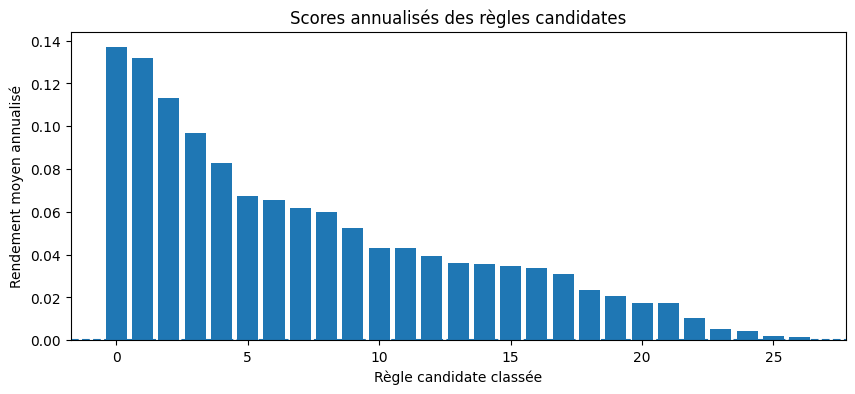

In [7]:
plt.figure(figsize=(10, 4))
plt.bar(range(len(results_df)), results_df["annualized_mean_return"])
plt.axhline(0, linestyle="--")
plt.title("Scores annualisés des règles candidates")
plt.xlabel("Règle candidate classée")
plt.ylabel("Rendement moyen annualisé")
plt.show()


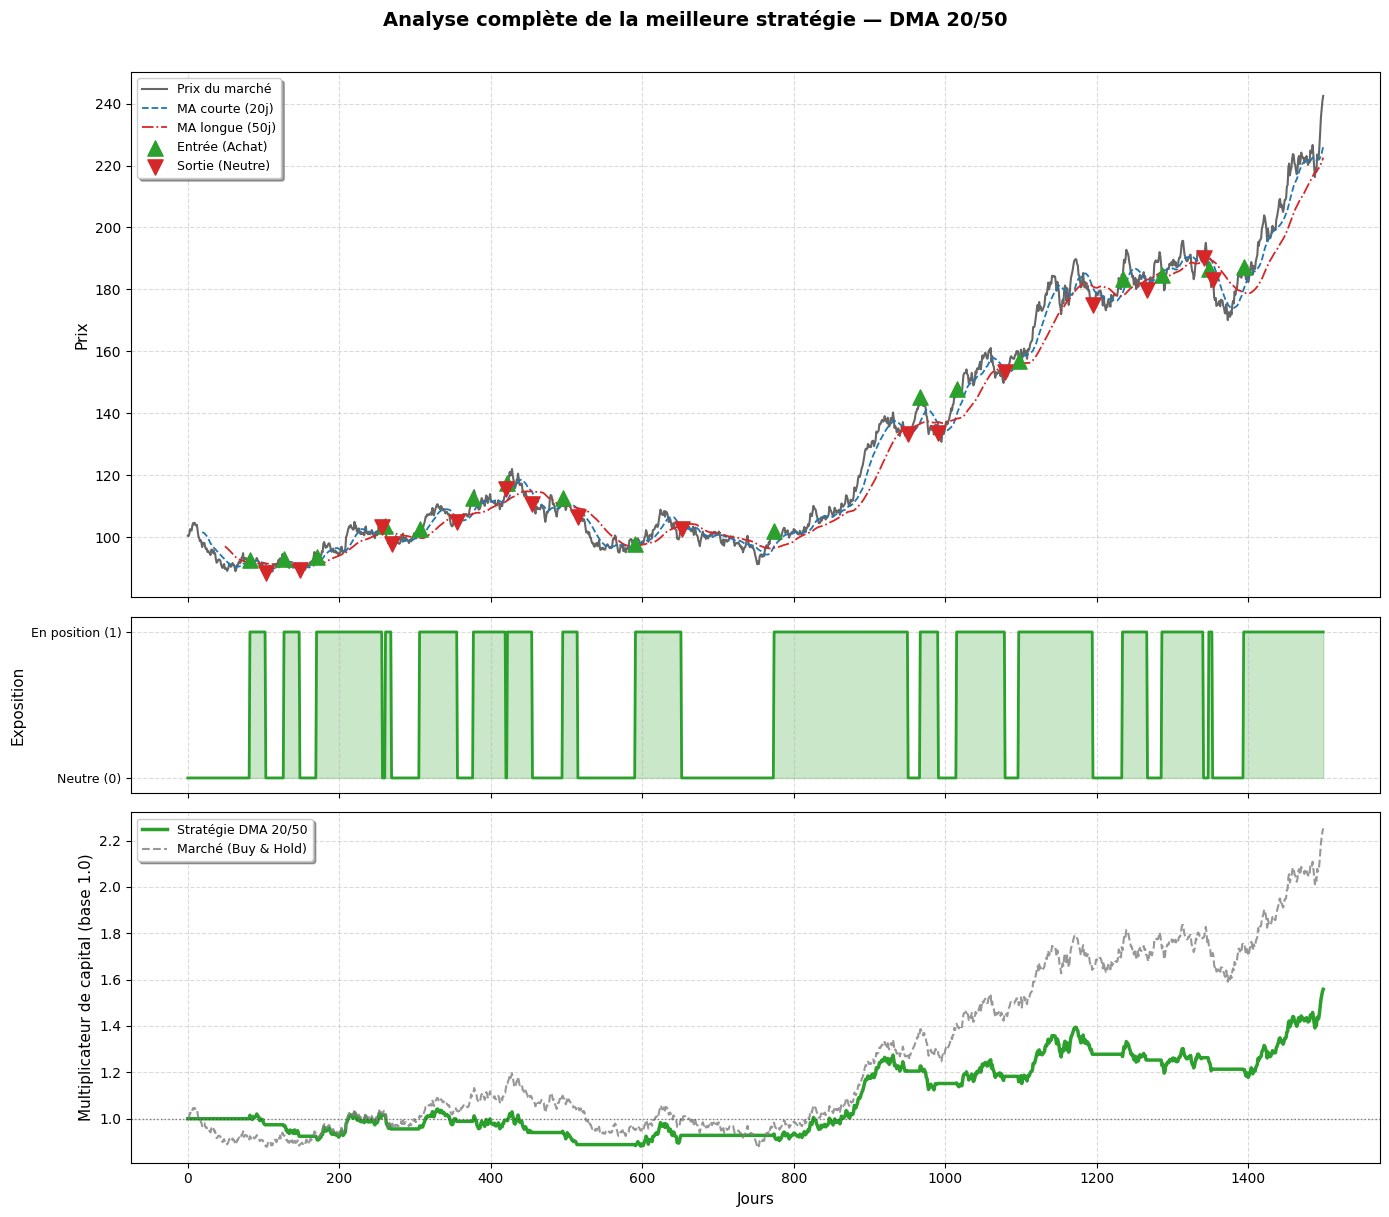

In [8]:
def plot_best_strategy(
    data: pd.DataFrame,
    short_window: int,
    long_window: int,
    *,
    price_col: str = "price",
    market_return_col: str = "market_return",
) -> tuple[pd.DataFrame, plt.Figure]:
    """
    Crée le DataFrame complet (signals, position, equity curve) et trace les
    trois panneaux d’analyse pour la meilleure combinaison de moyennes mobiles.
    """
    # 1️⃣ Copie et préparation du DataFrame
    df_best = data.copy()

    # Le rendement du marché est déjà présent sous la colonne "return"
    df_best[market_return_col] = df_best["return"]

    # Calcul des Moyennes Mobiles
    df_best["short_ma"] = df_best[price_col].rolling(short_window).mean()
    df_best["long_ma"]  = df_best[price_col].rolling(long_window).mean()

    # 2️⃣ Signaux & position
    df_best["signal"]   = (df_best["short_ma"] > df_best["long_ma"]).astype(int)
    df_best["position"] = df_best["signal"].shift(1).fillna(0)

    # Retour de la stratégie (position * rendement marché)
    df_best["strategy_return"] = df_best["position"] * df_best[market_return_col]

    # Courbes d'Equity cumulées
    df_best["equity_curve"]  = (1 + df_best["strategy_return"]).cumprod()
    df_best["market_equity"] = (1 + df_best[market_return_col]).cumprod()

    # 3️⃣ Détection des points d’entrée / sortie (buy/sell)
    df_best["buy_trigger"]  = (df_best["position"] == 1) & (df_best["position"].shift(1) == 0)
    df_best["sell_trigger"] = (df_best["position"] == 0) & (df_best["position"].shift(1) == 1)

    buy_signals  = df_best[df_best["buy_trigger"]]
    sell_signals = df_best[df_best["sell_trigger"]]

    # 4️⃣ Figure à 3 panneaux
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(14, 12),
        sharex=True,
        dpi=100,
        gridspec_kw={"height_ratios": [3, 1, 2]}
    )
    fig.suptitle(
        f"Analyse complète de la meilleure stratégie — DMA {short_window}/{long_window}",
        fontsize=14, fontweight="bold", y=1.01
    )

    # Panneau 1 : Prix + MA + signaux
    ax1.plot(df_best[price_col], label="Prix du marché", color="#333333", alpha=0.75, linewidth=1.5)
    ax1.plot(df_best["short_ma"], label=f"MA courte ({short_window}j)", color="#1f77b4", linestyle="--", linewidth=1.3)
    ax1.plot(df_best["long_ma"],  label=f"MA longue ({long_window}j)", color="#d62728", linestyle="-.", linewidth=1.3)

    ax1.scatter(buy_signals.index,  buy_signals[price_col],
                color="#2ca02c", marker="^", s=120, zorder=5, label="Entrée (Achat)")
    ax1.scatter(sell_signals.index, sell_signals[price_col],
                color="#d62728", marker="v", s=120, zorder=5, label="Sortie (Neutre)")

    ax1.set_ylabel("Prix", fontsize=11)
    ax1.legend(loc="upper left", frameon=True, shadow=True, fontsize=9)
    ax1.grid(True, linestyle="--", alpha=0.45)

    # Panneau 2 : Exposition
    ax2.fill_between(df_best.index, df_best["position"],
                     color="#2ca02c", alpha=0.25, label="Exposé au marché")
    ax2.plot(df_best["position"], color="#2ca02c", linewidth=2)
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(["Neutre (0)", "En position (1)"], fontsize=9)
    ax2.set_ylabel("Exposition", fontsize=11)
    ax2.set_ylim(-0.1, 1.1)
    ax2.grid(True, linestyle="--", alpha=0.45)

    # Panneau 3 : Equity Curve
    ax3.plot(df_best["equity_curve"], label=f"Stratégie DMA {short_window}/{long_window}",
             color="#2ca02c", linewidth=2.5)
    ax3.plot(df_best["market_equity"], label="Marché (Buy & Hold)",
             color="#7f7f7f", linestyle="--", alpha=0.8, linewidth=1.5)
    ax3.axhline(1.0, color="#333333", linestyle=":", linewidth=1, alpha=0.6)

    ax3.set_ylabel("Multiplicateur de capital (base 1.0)", fontsize=11)
    ax3.set_xlabel("Jours", fontsize=11)
    ax3.legend(loc="upper left", frameon=True, shadow=True, fontsize=9)
    ax3.grid(True, linestyle="--", alpha=0.45)

    plt.tight_layout()
    plt.show()

    return df_best, fig

# Paramètres à analyser (ex: 20 jours pour la courte, 50 jours pour la longue)
best_short = 20
best_long  = 50

# Génération en utilisant le DataFrame `data` existant déjà généré à l'étape 5
df_best, fig = plot_best_strategy(data, best_short, best_long)


## 10. Voir la meilleure règle comme un piège statistique

Supposons qu’on teste $N$ règles.

Même si chaque règle n’a aucun edge réel, certaines auront un bon résultat historique par chance.

Plus $N$ augmente, plus le maximum observé augmente naturellement.

C’est le cœur du **biais de minage de données** :

$$
\max(R_1, R_2, ..., R_N)
$$

n’est pas une observation neutre.

C’est une observation sélectionnée parce qu’elle est extrême.

> La meilleure règle d’un grand univers est statistiquement suspecte par défaut.


## 11. Mini-simulation : plus on teste, plus le meilleur résultat monte

On va simuler des univers de règles sans talent.

Chaque règle aura un score aléatoire centré sur zéro.

Puis on regardera le meilleur score obtenu quand on teste :

- 5 règles ;
- 20 règles ;
- 100 règles ;
- 500 règles ;
- 2000 règles.

L’objectif est de sentir l’Eurêka :

> Même sans edge, le maximum devient impressionnant quand l’univers de recherche grandit.


In [9]:
np.random.seed(123)

universe_sizes = [5, 20, 100, 500, 2000]
n_experiments = 2000

simulation_summary = []

for n_rules in universe_sizes:
    best_scores = []

    for _ in range(n_experiments):
        fake_scores = np.random.normal(loc=0, scale=1, size=n_rules)
        best_scores.append(fake_scores.max())

    simulation_summary.append({
        "number_of_rules_tested": n_rules,
        "average_best_score": np.mean(best_scores),
        "p95_best_score": np.percentile(best_scores, 95)
    })

simulation_df = pd.DataFrame(simulation_summary)
simulation_df


,number_of_rules_tested,average_best_score,p95_best_score
0,5,1.170603,2.321177
1,20,1.883674,2.826870
2,100,2.501682,3.271371
3,500,3.017033,3.685167
4,2000,3.439128,4.040171


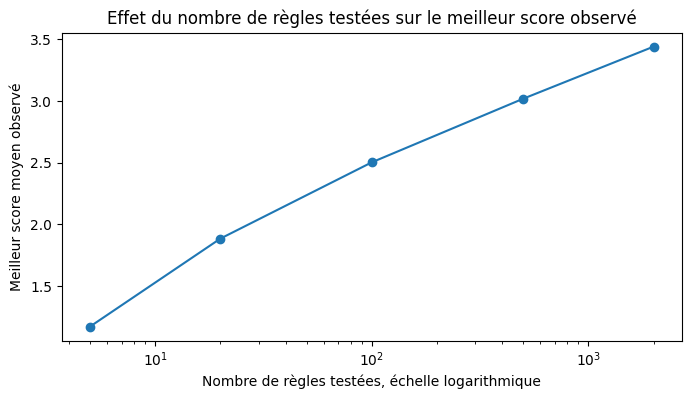

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(simulation_df["number_of_rules_tested"], simulation_df["average_best_score"], marker="o")
plt.xscale("log")
plt.title("Effet du nombre de règles testées sur le meilleur score observé")
plt.xlabel("Nombre de règles testées, échelle logarithmique")
plt.ylabel("Meilleur score moyen observé")
plt.show()


## 12. L’Eurêka final

> **Eurêka :** le problème n’est pas seulement que la meilleure règle est bonne. Le problème est qu’elle a été choisie parce qu’elle était la meilleure.

C’est une différence énorme.

Une stratégie qui obtient un bon score seule est une observation.

Une stratégie qui obtient le meilleur score parmi des milliers de tests est une statistique extrême.

Donc elle nécessite une correction spécifique.

C’est pour cela que David Aronson insiste sur les procédures comme :

- le **White’s Reality Check** ;
- les méthodes de **Bootstrap** adaptées au data mining ;
- les tests qui évaluent la meilleure règle en tenant compte de tout l’univers testé.


## 13. Checklist EBTA pour utiliser la rule searching proprement

| Question | Pourquoi elle compte |
|---|---|
| Ai-je défini l’univers avant de tester ? | Pour éviter de modifier les règles après coup |
| Combien de règles ai-je réellement testées ? | Pour mesurer l’ampleur du biais de sélection |
| Les familles de règles sont-elles documentées ? | Pour savoir quelle philosophie de marché est testée |
| Le meilleur résultat est-il corrigé du data mining ? | Pour éviter de confondre chance et edge |
| Ai-je un test hors-échantillon propre ? | Pour vérifier la robustesse après sélection |

> En EBTA, la recherche de règles n’est acceptable que si l’univers testé est explicite, documenté et statistiquement corrigé.


## 14. Résumé ultra-simple

La **rule searching**, c’est :

- tester plusieurs logiques de trading ;
- tester plusieurs paramètres pour chaque logique ;
- scorer toutes les règles ;
- sélectionner la meilleure ;
- puis corriger le fait qu’on a sélectionné un maximum.

La phrase à retenir :

> Plus tu cherches large, plus tu dois être sévère dans la validation statistique.


## 15. Annexe — texte source fourni

Le texte ci-dessous est conservé comme source de départ du notebook.


### **CH 6 : RULE DATA MINING AS A SPECIFICATION SEARCH - RULE SEARCHING**

Cette section définit une forme plus large de minage de données appelée la « recherche de règles » (*rule searching*), qui dépasse le simple ajustement de paramètres pour explorer diverses logiques de marché.,

#### **Idées clés :**
*   **Élargissement de l'univers :** Contrairement à l'optimisation, la recherche de règles explore des univers où les candidats diffèrent par leur forme conceptuelle (ex: RSI vs Moyennes Mobiles) et leurs paramètres.,
*   **Complexité fixe :** Bien que les formes varient, le nombre de paramètres définissant chaque règle reste prédéfini et fixe durant toute la recherche.,
*   **Catégorisation thématique :** Les règles sont regroupées par philosophies de marché (tendance, contre-tendance, divergence, etc.).,
*   **Biais persistant :** Cette méthode, bien que plus vaste, reste totalement sujette au biais de minage de données car elle repose toujours sur la sélection du maximum statistique.,

#### **Référence :**
*Types of Searches: Rule Searching*, Chapitre 6, pages 266 à 267.,

#### **Citation Directe :**
« A broader version of data mining is rule searching. Here, the universe of rules differ in their conceptual form as well as their parameter values. » (Page 266).
*(Traduction : Une version plus large du minage de données est la recherche de règles. Ici, l'univers des règles diffère par leur forme conceptuelle ainsi que par les valeurs de leurs paramètres.)*

---

#### **Vision Macro :**
L'enjeu est de découvrir quelle « philosophie » de trading est la plus adaptée à un marché donné sur une période spécifique. David Aronson explique que limiter la recherche à une seule forme de règle (optimisation) revient à assumer que l'on connaît déjà la logique gagnante. La recherche de règles permet de mettre en compétition différentes théories de l'analyse technique (le marché est-il en tendance ? est-il en sur-achat ? y a-t-il une divergence ?). C'est une démarche d'exploration intellectuelle automatisée qui cherche à identifier le signal le plus robuste parmi une multitude de concepts concurrents.,

---

#### **Vision Micro :**
Le mécanisme de la recherche de règles se distingue par les points techniques suivants :
1.  **Indépendance des formes :** L'univers de recherche contient des formalisations mathématiques différentes. Par exemple, un croisement de moyennes mobiles et une cassure de canal (Channel Breakout) sont deux formes distinctes de suivi de tendance.,
2.  **Paramètres multiples :** Chaque forme possède ses propres variables. La recherche balaie non seulement les différentes formes, mais aussi toutes les combinaisons de paramètres pour chaque forme.,
3.  **Absence de synthèse :** Dans cette procédure, les règles ne sont pas combinées entre elles pour en former de plus complexes (ce qui relève de l'induction). Chaque règle est testée de manière autonome avec une complexité (nombre d'opérateurs) fixée au départ.,
4.  **Univers de recherche (Case Study) :** Aronson illustre cela dans sa propre étude en testant 6 402 règles réparties en trois thèmes majeurs :
    *   **Tendances :** Basé sur l'opérateur de cassure de canal (CBO).,
    *   **Extrêmes et Transitions :** Règles de retour à la moyenne (mean-reversion) ou de valeurs extrêmes.,
    *   **Divergences :** Comparaison de la tendance du prix avec une série de données compagne.,

---

#### **Résumé Simplifié :**
L'optimisation des paramètres, c'est tester 100 dosages de sucre pour un gâteau. La recherche de règles, c'est tester 100 recettes de gâteaux, 100 recettes de tartes et 100 recettes de biscuits pour voir laquelle est la plus rentable., C'est une méthode de recherche beaucoup plus puissante, mais elle multiplie le nombre de tests, ce qui augmente le risque de tomber sur une stratégie « gagnante » par pure chance.,

---

#### **Actions Concrètes :**
*   **Diversifier les logiques :** Ne testez pas seulement des variantes d'un seul indicateur ; incluez des règles de tendance, de momentum et de volatilité dans le même processus de minage.,
*   **Maintenir une syntaxe rigoureuse :** Utilisez un langage de script (ISL) pour définir clairement chaque forme de règle avant le lancement des tests.,
*   **Documenter l'énumération :** Calculez précisément la taille de l'univers total (ex: 11 look-backs x 39 séries de données = 429 règles de tendance). Ce chiffre est indispensable pour corriger le biais final.,

---

#### **À retenir absolument :**
*   **Rule Searching** = Plusieurs formes logiques + Plusieurs paramètres.,
*   Chaque règle a une **complexité fixe** durant la recherche.,
*   Les catégories incluent le **Trend**, le **Mean Reversion** et la **Divergence**.,
*   Plus l'univers est large, plus le **biais de minage de données** est élevé.,
*   C'est la méthode utilisée par Aronson pour tester les **6 402 règles** sur le S&P 500.,

J'ai terminé l'analyse de la recherche de règles comme type de minage de données selon le protocole EBTA.